[Device] Using mps
Device: mps

ANALYSE DU MODE : exclusive
Saved: docs/report/images/training_exclusive.png
Saved: docs/report/images/training_exclusive.pdf


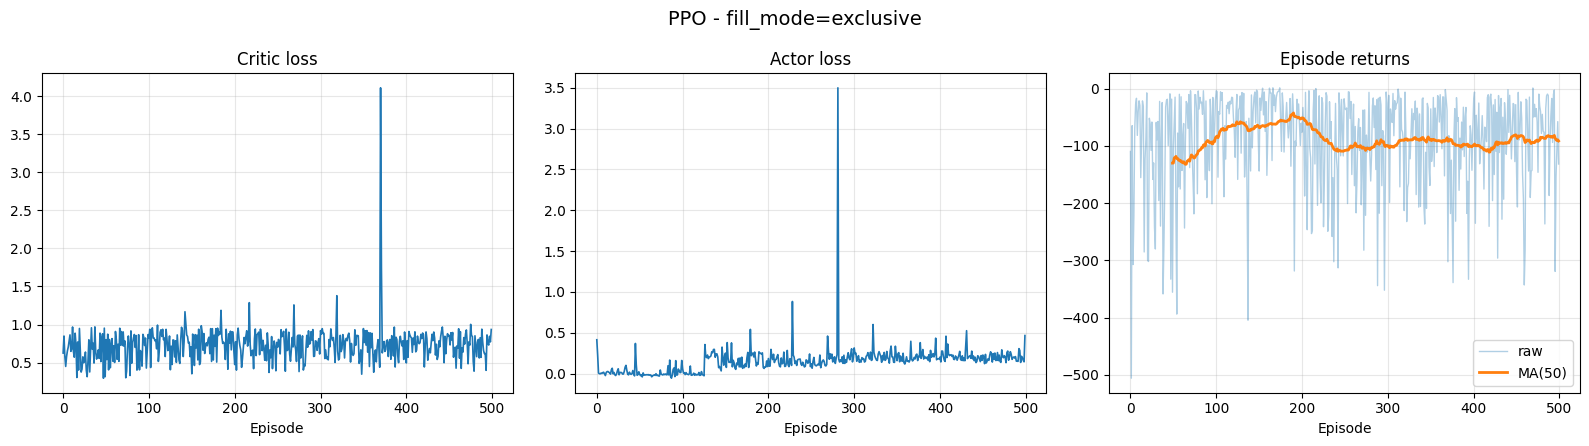

=== Rollout summary ===
steps           : 256
final inventory : 6.0000
final cash      : -599.5342
final mtm       : 6.3652
cum reward      : -54.1278
mean delta_bid  : 0.0065
mean delta_ask  : 0.0434
mean q_bid      : 1.4054
mean q_ask      : 8.5911
Saved: docs/report/images/timeseries_exclusive.png


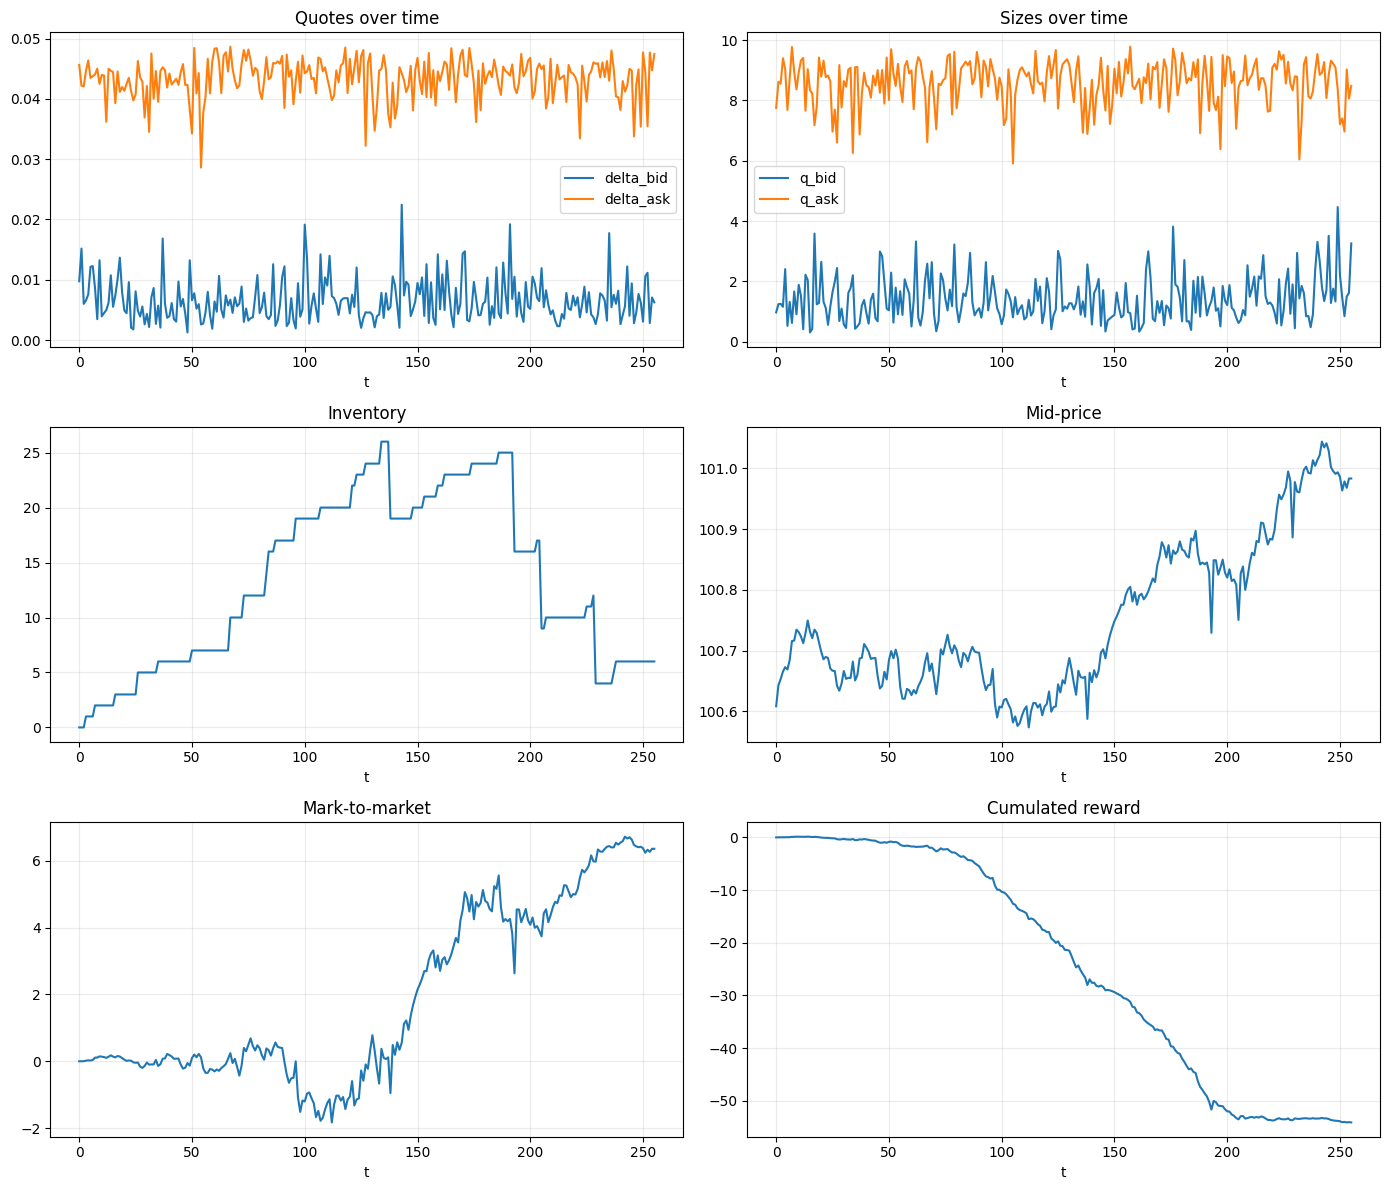

Saved: docs/report/images/state_links_exclusive.png


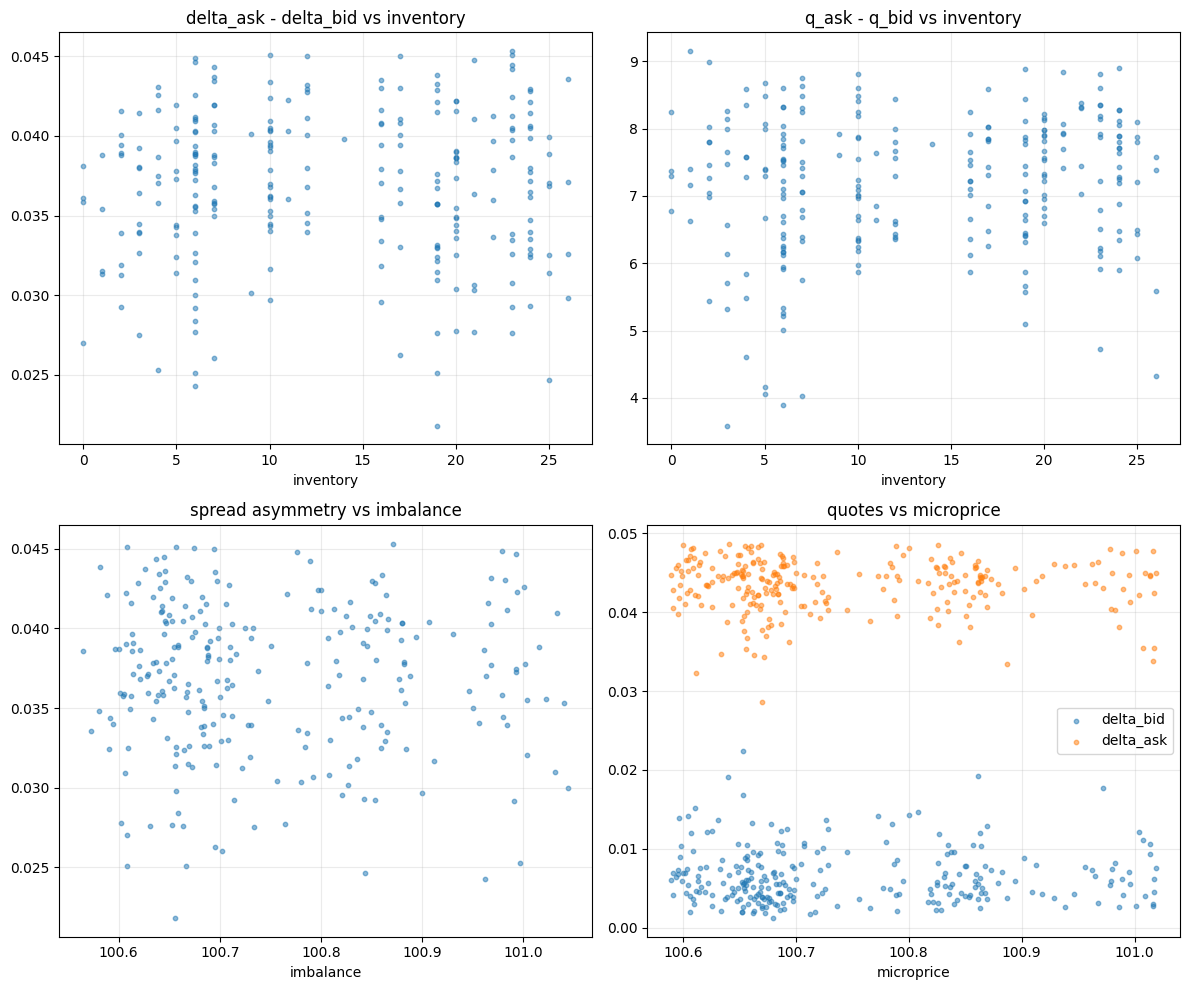


ANALYSE DU MODE : independent
Saved: docs/report/images/training_independent.png
Saved: docs/report/images/training_independent.pdf


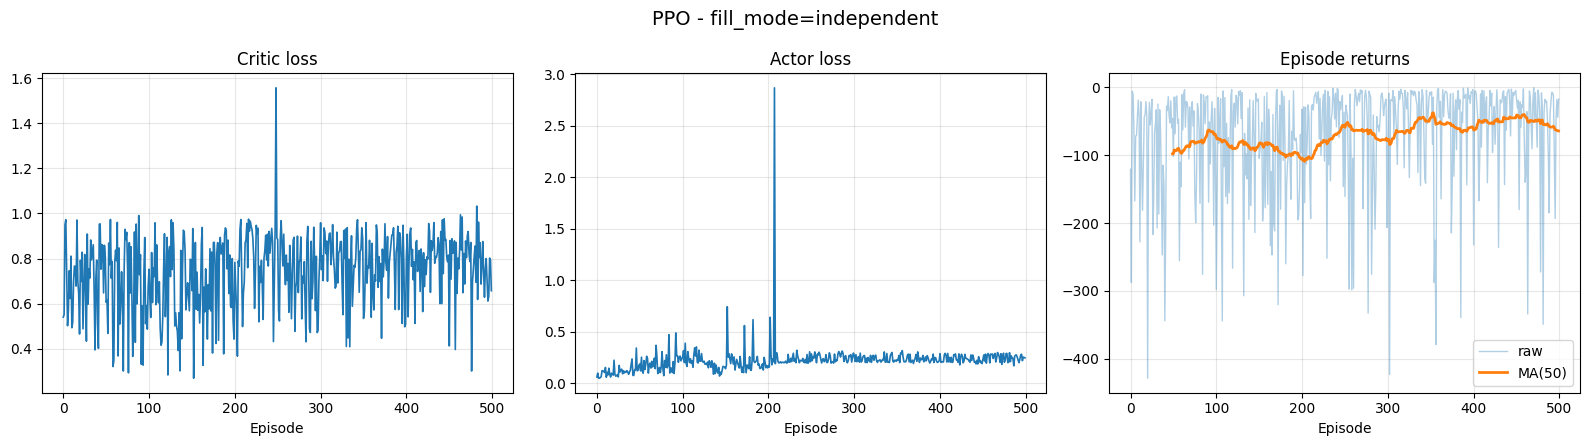

=== Rollout summary ===
steps           : 256
final inventory : -5.0000
final cash      : 505.4987
final mtm       : 0.6326
cum reward      : -4.6699
mean delta_bid  : 0.0066
mean delta_ask  : 0.0065
mean q_bid      : 3.8520
mean q_ask      : 1.3804
Saved: docs/report/images/timeseries_independent.png


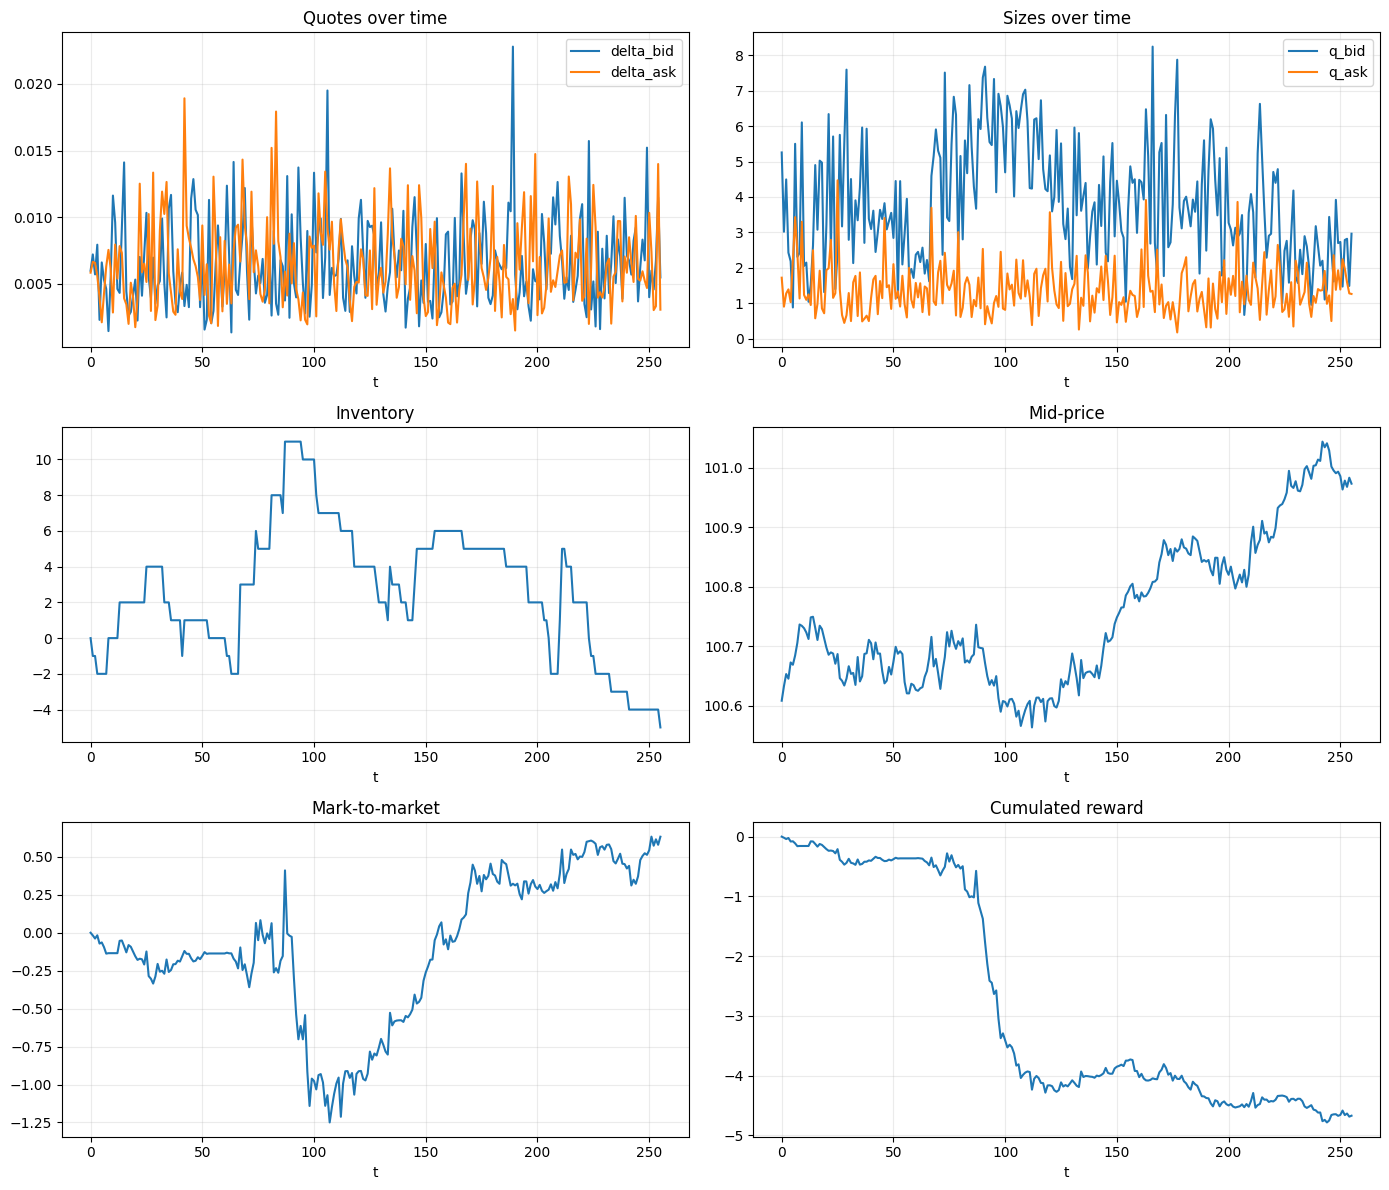

Saved: docs/report/images/state_links_independent.png


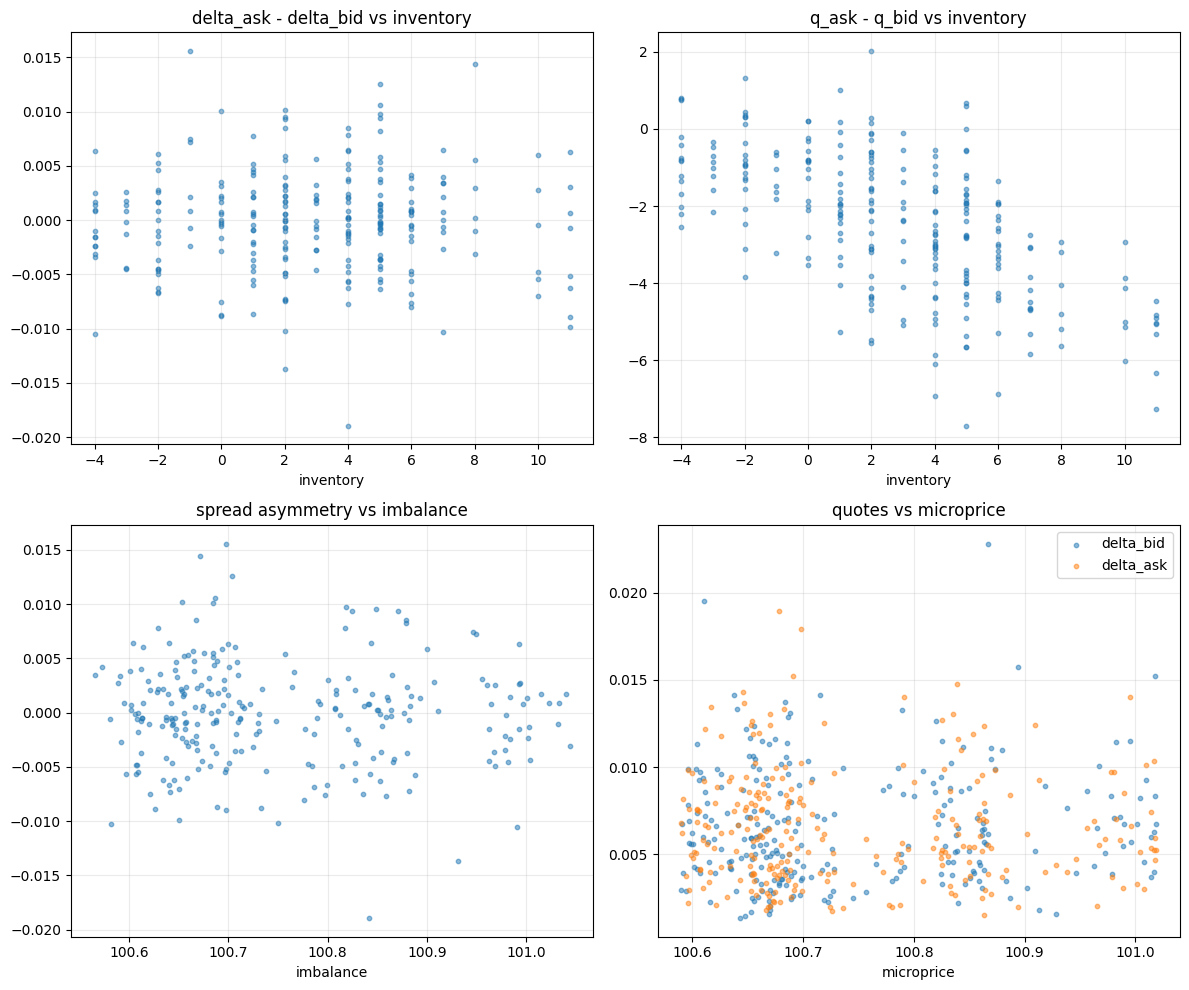


ANALYSE DU MODE : hawkes
Saved: docs/report/images/training_hawkes.png
Saved: docs/report/images/training_hawkes.pdf


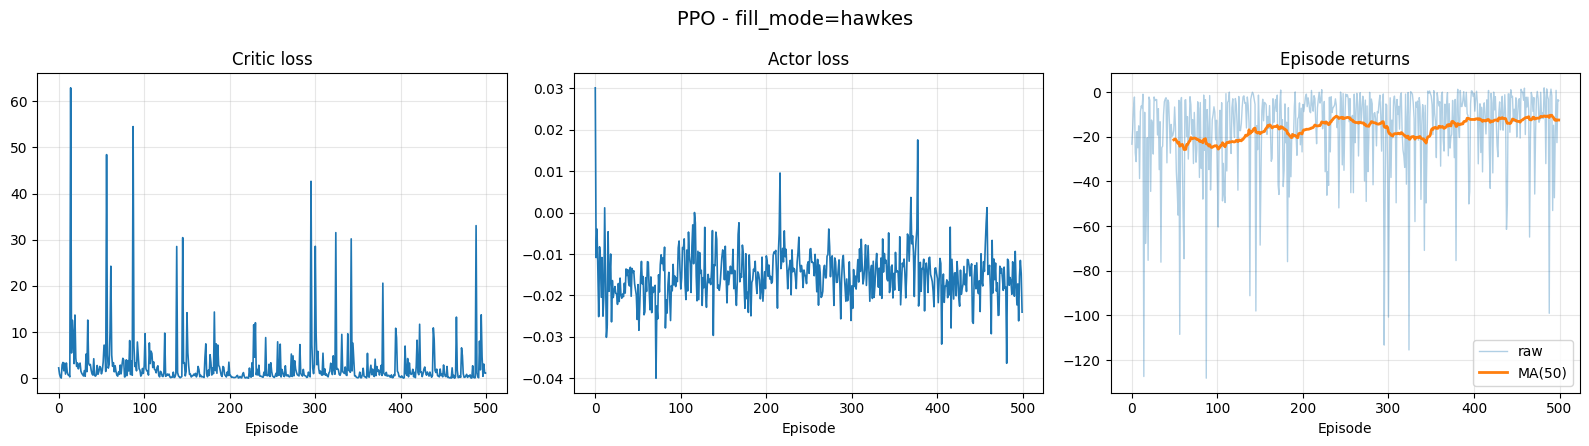

=== Rollout summary ===
steps           : 256
final inventory : -17.0000
final cash      : 1713.9347
final mtm       : -2.7802
cum reward      : -34.6257
mean delta_bid  : 0.0359
mean delta_ask  : 0.0287
mean q_bid      : 1.2940
mean q_ask      : 1.5456
Saved: docs/report/images/timeseries_hawkes.png


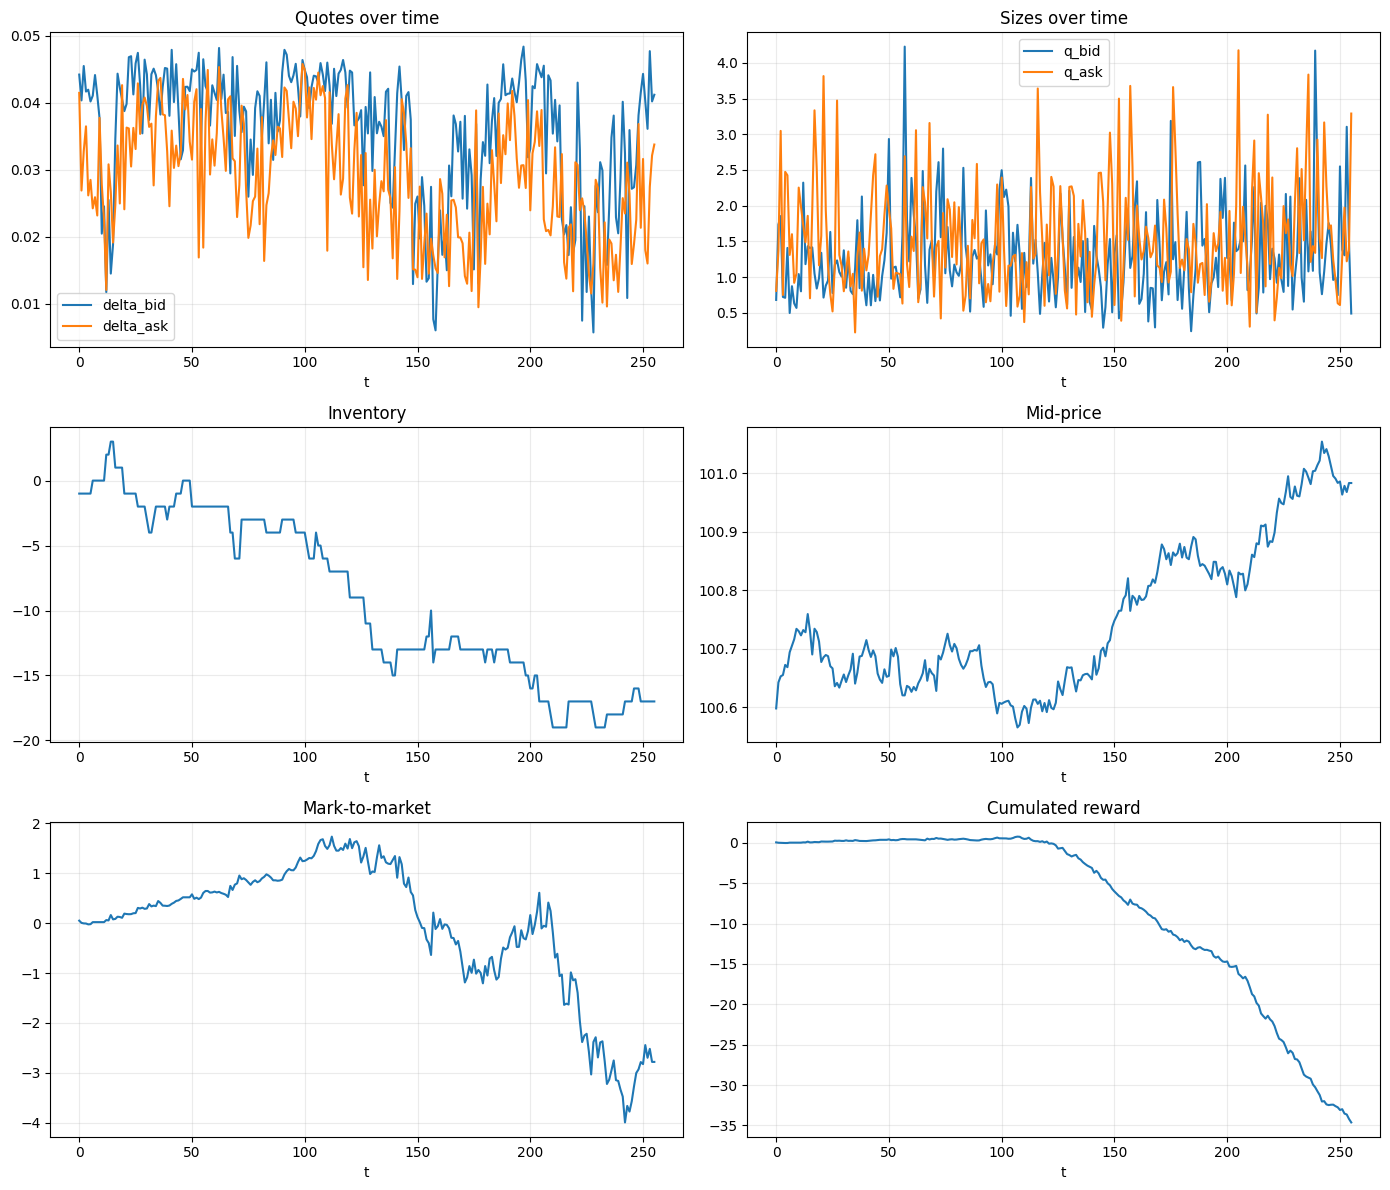

Saved: docs/report/images/state_links_hawkes.png


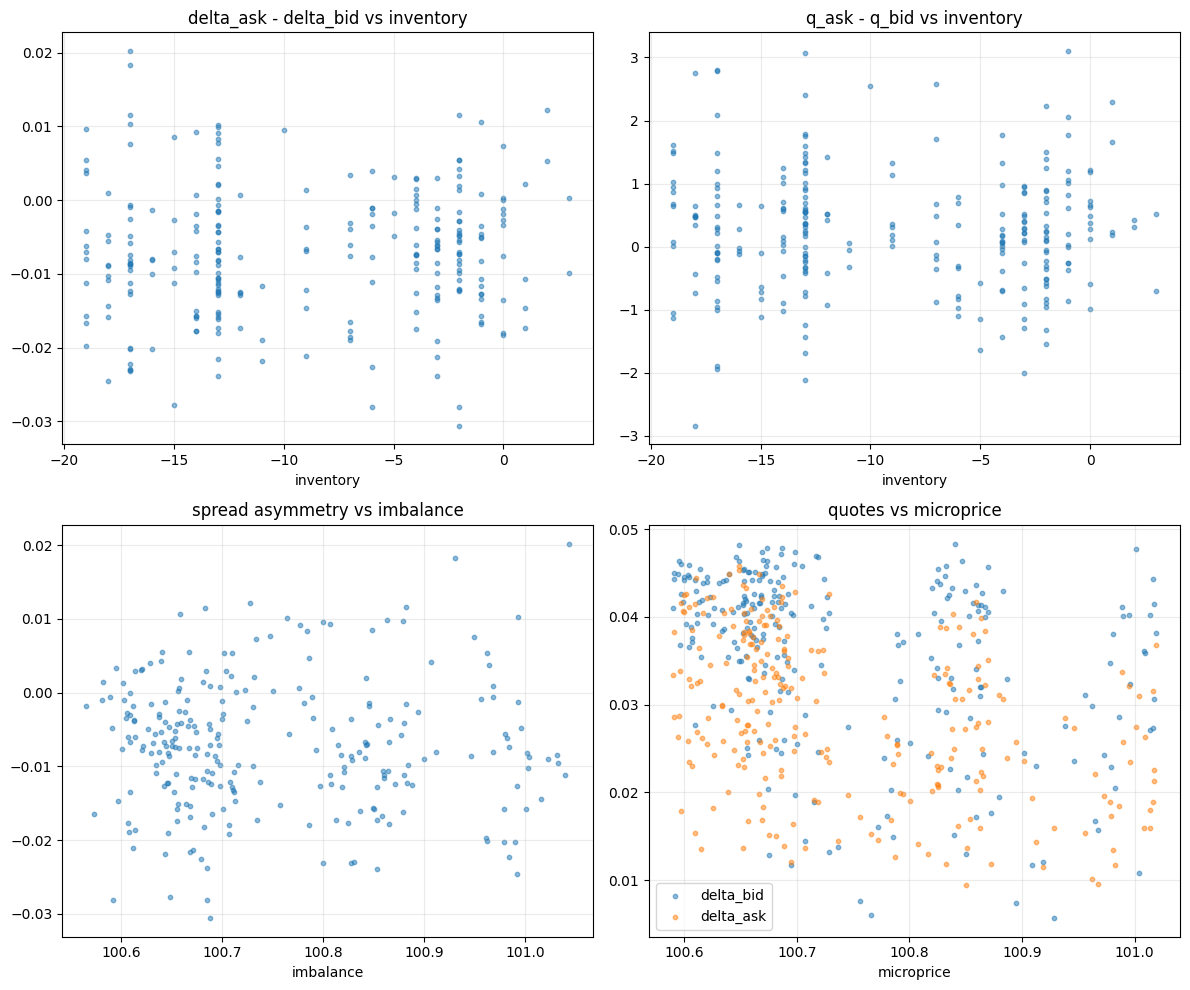

In [1]:
import os
os.chdir("/Users/franciscegoat/mm-rl")
import json
import torch
import importlib.util

from src.envs.env_toy_mm import MMSimulator
from src.ppo.networks import ActorNet
from src.utils.device import get_device

# =========================================================
# Chargement dynamique des deux fichiers si besoin
# =========================================================
def load_module_from_path(module_name, file_path):
    spec = importlib.util.spec_from_file_location(module_name, file_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

# Si tes fichiers sont dans src/utils, remplace simplement par des imports classiques :
from src.utils.visualisation import plot_training_results
from src.utils.policy_diagnostics import rollout_detailed, plot_policy_timeseries, plot_policy_state_links, print_rollout_summary

#vis = load_module_from_path("visualisation", "data/visualisation.py")
#diag = load_module_from_path("policy_diagnostics", "data/policy_diagnostics.py")

plot_training_results = plot_training_results
rollout_detailed = rollout_detailed
plot_policy_timeseries = plot_policy_timeseries
plot_policy_state_links = plot_policy_state_links
print_rollout_summary = print_rollout_summary

# =========================================================
# Paramètres généraux
# =========================================================
device = get_device()
print("Device:", device)

base_dir = "logs/fill_mode_comparison"
fill_modes = ["exclusive", "independent", "hawkes"]

csv_path = "data/raw/toy_lob_non_stationnary_seed42.csv"

# =========================================================
# Boucle d'analyse
# =========================================================
for fill_mode in fill_modes:
    print("\n" + "=" * 80)
    print(f"ANALYSE DU MODE : {fill_mode}")
    print("=" * 80)

    run_dir = os.path.join(base_dir, fill_mode)

    # -------------------------
    # 1. Charger config / history
    # -------------------------
    with open(os.path.join(run_dir, "config.json"), "r") as f:
        config = json.load(f)

    with open(os.path.join(run_dir, "history.json"), "r") as f:
        history = json.load(f)

    # -------------------------
    # 2. Courbes d'entraînement
    # -------------------------
    plot_training_results(
        history,
        label=f"PPO - fill_mode={fill_mode}",
        save=True,
        save_dir="docs/report/images",
        filename=f"training_{fill_mode}"
    )

    # -------------------------
    # 3. Recréer env
    # -------------------------
    env = MMSimulator(
        csv_path=csv_path,
        seed=config.get("seed", 42),
        p_fill_base=config.get("p_fill_base", 0.30),
        eta_inv=config.get("eta_inv", 1e-3),
        inv_max=config.get("inv_max", 50),
        inv_min=config.get("inv_min", -50),
        phi_as=config.get("phi_as", 0.02),
        state_mode=config.get("state_mode", "article_like"),
        dynamic_mode=config.get("dynamic_mode", "impact"),
        fill_mode=config.get("fill_mode", fill_mode),
    )

    # -------------------------
    # 4. Recréer acteur
    # -------------------------
    actor = ActorNet(
        state_dim=config["state_dim"],
        hidden_size=config["hidden_size"],
        n_layers=config["n_layers"],
        action_dim=config["action_dim"],
        delta_min=config["delta_min"],
        delta_max=config["delta_max"],
    ).to(device)

    actor.load_state_dict(
        torch.load(os.path.join(run_dir, "actor.pt"), map_location=device)
    )
    actor.eval()

    # -------------------------
    # 5. Rollout détaillé
    # -------------------------
    traj = rollout_detailed(
        env=env,
        actor=actor,
        device=device,
        max_steps=config.get("max_steps", 256),
        random_reset=True,
        deterministic=False,   # mets True pour comparer ensuite
    )

    print_rollout_summary(traj)

    # -------------------------
    # 6. Diagnostics temporels
    # -------------------------
    plot_policy_timeseries(
        traj,
        save=True,
        save_dir="docs/report/images",
        prefix=f"timeseries_{fill_mode}"
    )

    # -------------------------
    # 7. Diagnostics action/état
    # -------------------------
    # Adapte les indices si ton ordre réel d'état diffère
    plot_policy_state_links(
        traj,
        env,
        inventory_index=-1,
        imbalance_index=2,
        microprice_index=3,
        save=True,
        save_dir="docs/report/images",
        prefix=f"state_links_{fill_mode}"
    )

In [2]:
import os 
os.chdir("/Users/franciscegoat/mm-rl")

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd

from src.envs.env_toy_mm import MMSimulator
from src.evaluation.baselines import AvellanedaStoikovPolicy
from src.ppo.networks import ActorNet

In [4]:
def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

device = get_device()
print("Device:", device)

Device: mps


In [5]:
csv_path = "data/raw/toy_lob.csv"
actor_path = "logs/fill_mode_comparison/hawkes/actor.pt"

In [6]:
def estimate_sigma_from_csv(csv_path, mid_col="mid"):
    df = pd.read_csv(csv_path)
    mids = df[mid_col].astype(float).values
    dmid = np.diff(mids)
    sigma = np.std(dmid)
    return float(max(sigma, 1e-8))

sigma_hat = estimate_sigma_from_csv(csv_path)
print("Sigma estimé:", sigma_hat)

Sigma estimé: 0.12862543956202477


In [7]:
max_steps = 150  # ajuste si besoin

env_ppo = MMSimulator(csv_path=csv_path, state_mode="article_like", dynamic_mode = "impact")
env_as  = MMSimulator(csv_path=csv_path, state_mode="article_like", dynamic_mode = "impact")

state_ppo = env_ppo.reset(max_steps=max_steps)
state_as  = env_as.reset(max_steps=max_steps)

print("state_dim env:", env_ppo.state_dim)
print("initial state shape:", state_ppo.shape)

state_dim = env_ppo.state_dim
action_dim = 1
hidden_size = 64
n_layers = 3
delta_min = 0.001
delta_max = 0.05

actor = ActorNet(
    state_dim=state_dim,
    action_dim=4,
    hidden_size=64,
    n_layers=3,
    delta_min=0.001,
    delta_max=0.05,
).to(device)

state_dict = torch.load(actor_path, map_location=device)

actor.load_state_dict(state_dict)
actor.eval()

print("Actor chargé correctement.")

state_dim env: 7
initial state shape: (7,)
Actor chargé correctement.


In [8]:
as_policy = AvellanedaStoikovPolicy(
    gamma=0.1,
    k=1.5,
    sigma=sigma_hat,
    q_bid=1.0,
    q_ask=1.0,
    min_spread=1e-4,
    max_spread=0.05,   # cohérent avec l'échelle du PPO actuel si delta_max ~ 0.05
)

In [9]:
def run_one_episode(env, policy_type, actor=None, as_policy=None, device=None, avellaneda_mode="symmetric"):
    state = env.reset(max_steps=max_steps)
    done = False
    t = 0

    inventory = []
    cash = []
    mtm = []
    rewards = []
    actions = []
    mids = []

    # horizon résiduel pour Avellaneda
    T = max_steps if max_steps is not None else len(env.data) - 1

    while not done:
        inv = float(env.inventory)
        mid = float(env.mid)
        tau = max(T - t, 1)

        if policy_type == "ppo":
            s = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                action, _, _ = actor.sample_action(s)
            action = action.squeeze(0).detach().cpu().numpy()

        elif policy_type == "avellaneda":
            action = as_policy.get_action_1d(
                mid=mid,
                inventory=inv,
                tau=tau,
                mode=avellaneda_mode,
            )
        else:
            raise ValueError(f"policy_type inconnu: {policy_type}")

        out = env.step(action)

        # le fichier affiché sur GitHub documente un retour à 3 objets,
        # mais on garde ici une gestion tolérante
        if len(out) == 3:
            next_state, reward, done = out
            info = {}
        elif len(out) == 4:
            next_state, reward, done, info = out
        else:
            raise ValueError("Signature inattendue de env.step(...)")

        inventory.append(float(env.inventory))
        cash.append(float(env.cash))
        mtm.append(float(env.cash + env.inventory * env.mid))
        rewards.append(float(reward))
        actions.append(np.asarray(action, dtype=float).reshape(-1).copy())
        mids.append(float(env.mid))

        state = next_state
        t += 1

    actions = np.array(actions)

    return {
        "inventory": np.array(inventory),
        "cash": np.array(cash),
        "mtm": np.array(mtm),
        "rewards": np.array(rewards),
        "actions": actions,
        "mid": np.array(mids),
        "cum_reward": float(np.sum(rewards)),
        "final_pnl": float(mtm[-1]),
    }

In [10]:
ppo_rollout = run_one_episode(
    env=env_ppo,
    policy_type="ppo",
    actor=actor,
    device=device,
)

as_rollout = run_one_episode(
    env=env_as,
    policy_type="avellaneda",
    as_policy=as_policy,
    avellaneda_mode="symmetric", 
)

print("PPO final pnl :", ppo_rollout["final_pnl"])
print("AS final pnl  :", as_rollout["final_pnl"])
print("PPO cum reward:", ppo_rollout["cum_reward"])
print("AS cum reward :", as_rollout["cum_reward"])

PPO final pnl : 18.498260088610323
AS final pnl  : 6.8718216377477574
PPO cum reward: 17.198360088610322
AS cum reward : 6.806621637747758


In [11]:
def summarize_rollout(name, rollout):
    print(f"===== {name} =====")
    print("final_pnl          :", rollout["final_pnl"])
    print("cum_reward         :", rollout["cum_reward"])
    print("mean_inventory     :", np.mean(rollout["inventory"]))
    print("mean_abs_inventory :", np.mean(np.abs(rollout["inventory"])))
    print("std_inventory      :", np.std(rollout["inventory"]))
    print("mean_mtm           :", np.mean(rollout["mtm"]))
    if rollout["actions"].ndim == 2 and rollout["actions"].shape[1] == 1:
        print("mean_action        :", np.mean(rollout["actions"][:, 0]))
        print("std_action         :", np.std(rollout["actions"][:, 0]))
    print()

summarize_rollout("PPO", ppo_rollout)
summarize_rollout("Avellaneda", as_rollout)

===== PPO =====
final_pnl          : 18.498260088610323
cum_reward         : 17.198360088610322
mean_inventory     : -8.333333333333334
mean_abs_inventory : 8.413333333333334
std_inventory      : 3.9474323581566564
mean_mtm           : 11.334112655081986

===== Avellaneda =====
final_pnl          : 6.8718216377477574
cum_reward         : 6.806621637747758
mean_inventory     : -0.8133333333333334
mean_abs_inventory : 1.68
std_inventory      : 1.8846278736722064
mean_mtm           : 4.5143181442494065
mean_action        : 0.031113763935863972
std_action         : 0.010022739134277477



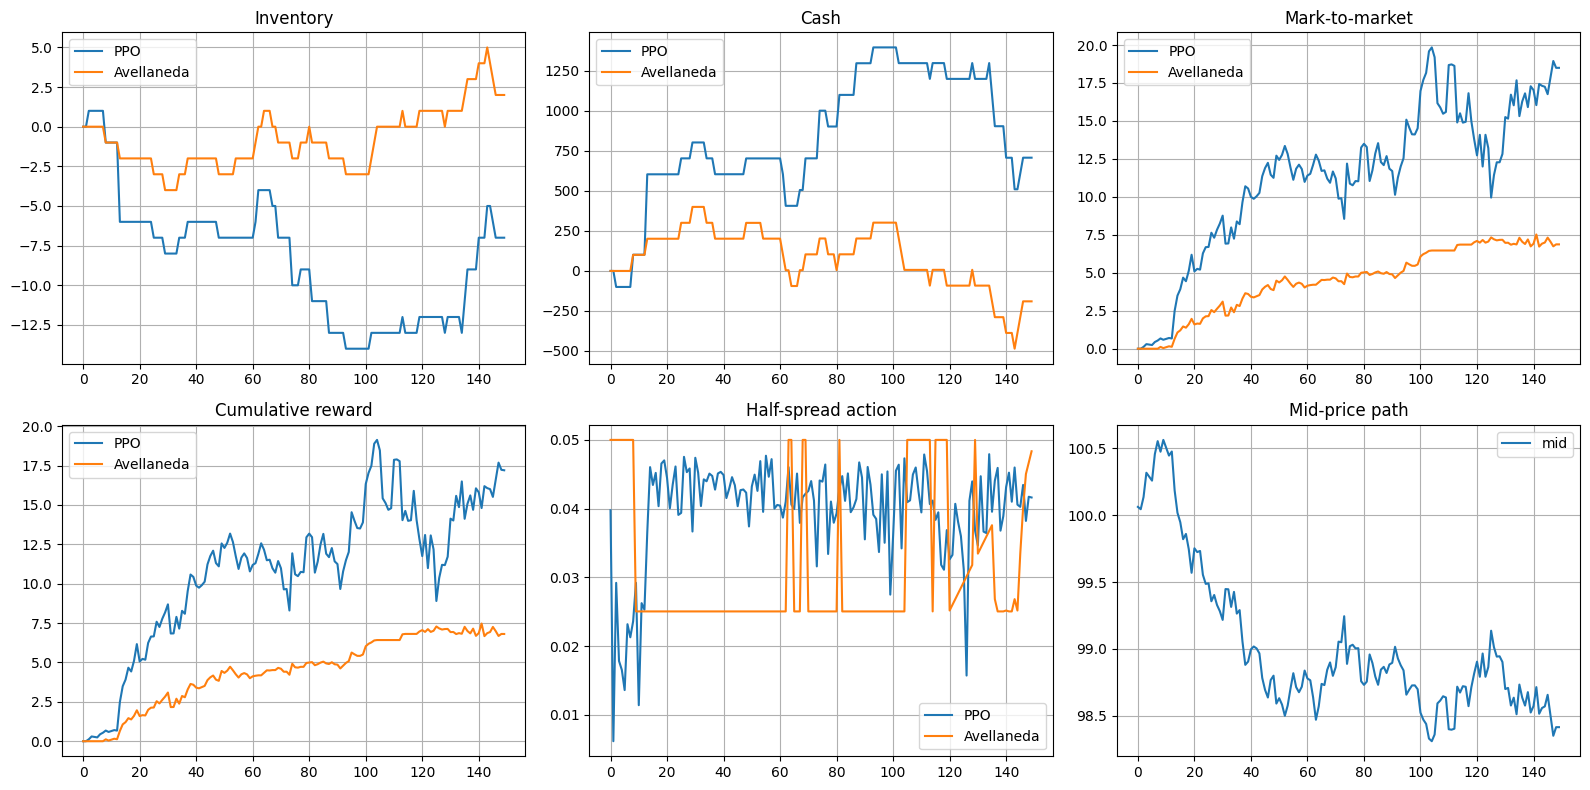

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0, 0].plot(ppo_rollout["inventory"], label="PPO")
axes[0, 0].plot(as_rollout["inventory"], label="Avellaneda")
axes[0, 0].set_title("Inventory")
axes[0, 0].grid(True)
axes[0, 0].legend()

axes[0, 1].plot(ppo_rollout["cash"], label="PPO")
axes[0, 1].plot(as_rollout["cash"], label="Avellaneda")
axes[0, 1].set_title("Cash")
axes[0, 1].grid(True)
axes[0, 1].legend()

axes[0, 2].plot(ppo_rollout["mtm"], label="PPO")
axes[0, 2].plot(as_rollout["mtm"], label="Avellaneda")
axes[0, 2].set_title("Mark-to-market")
axes[0, 2].grid(True)
axes[0, 2].legend()

axes[1, 0].plot(np.cumsum(ppo_rollout["rewards"]), label="PPO")
axes[1, 0].plot(np.cumsum(as_rollout["rewards"]), label="Avellaneda")
axes[1, 0].set_title("Cumulative reward")
axes[1, 0].grid(True)
axes[1, 0].legend()

axes[1, 1].plot(ppo_rollout["actions"][:, 0], label="PPO")
axes[1, 1].plot(as_rollout["actions"][:, 0], label="Avellaneda")
axes[1, 1].set_title("Half-spread action")
axes[1, 1].grid(True)
axes[1, 1].legend()

axes[1, 2].plot(ppo_rollout["mid"], label="mid")
axes[1, 2].set_title("Mid-price path")
axes[1, 2].grid(True)
axes[1, 2].legend()

plt.tight_layout()
plt.show()

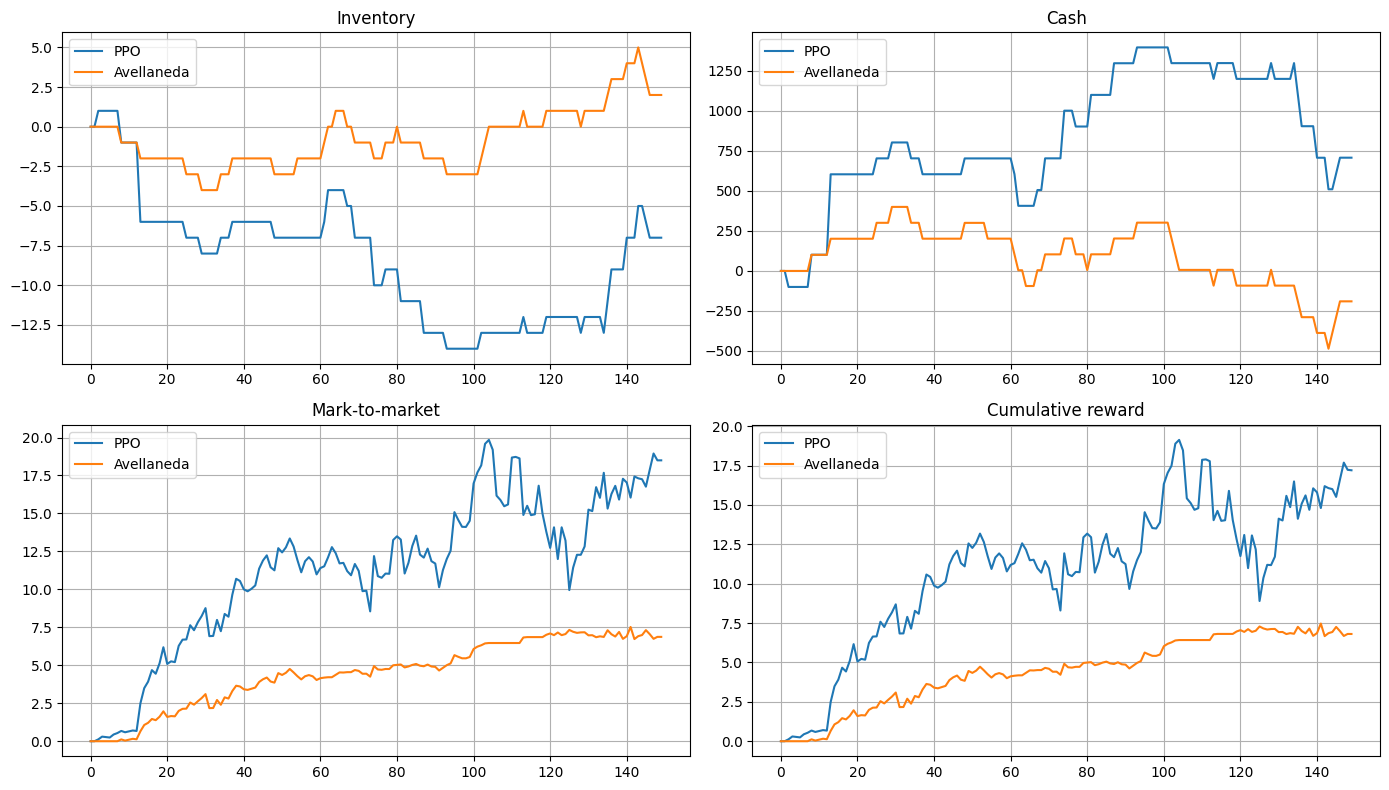

In [13]:
import os
os.makedirs("docs/report/images", exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(ppo_rollout["inventory"], label="PPO")
axes[0, 0].plot(as_rollout["inventory"], label="Avellaneda")
axes[0, 0].set_title("Inventory")
axes[0, 0].grid(True)
axes[0, 0].legend()

axes[0, 1].plot(ppo_rollout["cash"], label="PPO")
axes[0, 1].plot(as_rollout["cash"], label="Avellaneda")
axes[0, 1].set_title("Cash")
axes[0, 1].grid(True)
axes[0, 1].legend()

axes[1, 0].plot(ppo_rollout["mtm"], label="PPO")
axes[1, 0].plot(as_rollout["mtm"], label="Avellaneda")
axes[1, 0].set_title("Mark-to-market")
axes[1, 0].grid(True)
axes[1, 0].legend()

axes[1, 1].plot(np.cumsum(ppo_rollout["rewards"]), label="PPO")
axes[1, 1].plot(np.cumsum(as_rollout["rewards"]), label="Avellaneda")
axes[1, 1].set_title("Cumulative reward")
axes[1, 1].grid(True)
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("docs/report/images/ppo_vs_avellaneda_one_episode.png", dpi=200, bbox_inches="tight")
plt.show()

(array([[150.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [150.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   1.,   8.,   7.,  15.,  16.,  18.,  17.,  14.,   9.,   8.,
          10.,   6.,   4.,   6.,   3.,   2.,   0.,   1.,   0.,   1.,   1.,
           1.,   0.,   1.,   1.,   0.,   0.,   0.,   0.],
        [  0.,   3.,   4.,  10.,   7.,  13.,  18.,  12.,  14.,   9.,  13.,
           6.,   5.,   4.,   8.,   4.,   4.,   0.,   2.,   5.,   4.,   2.,
           0.,   0.,   1.,   0.,   0.,   0.,   1.,   1.]]),
 array([0.00617013, 0.15722436, 0.30827858, 0.45933281, 0.61038704,
        0.76144127, 0.9124955 , 1.06354972, 1.21460395, 1.36565818,
        1.51671241, 1.66776664

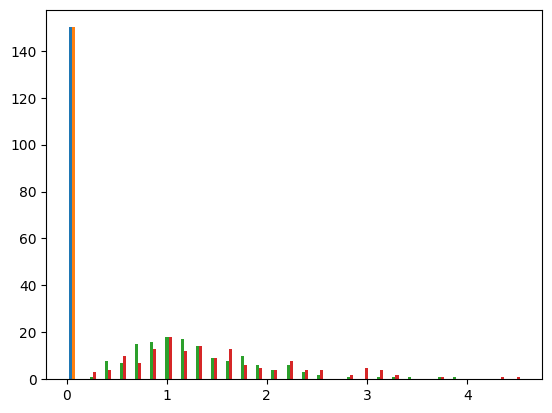

In [14]:
plt.hist(ppo_rollout["actions"], bins=30)

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def plot_action_histograms(actions):
    actions = np.asarray(actions)

    if actions.ndim == 1:
        actions = actions.reshape(-1, 1)

    n_dim = actions.shape[1]

    if n_dim == 1:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.hist(actions[:, 0], bins=40)
        ax.set_title("Histogram of action")
        ax.set_xlabel("action")
        ax.grid(True)
        plt.tight_layout()
        plt.show()
        return

    labels = ["delta_bid", "delta_ask", "q_bid", "q_ask"][:n_dim]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.ravel()

    for i in range(n_dim):
        axes[i].hist(actions[:, i], bins=40)
        axes[i].set_title(f"Histogram of {labels[i]}")
        axes[i].set_xlabel(labels[i])
        axes[i].grid(True)

    for j in range(n_dim, 4):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

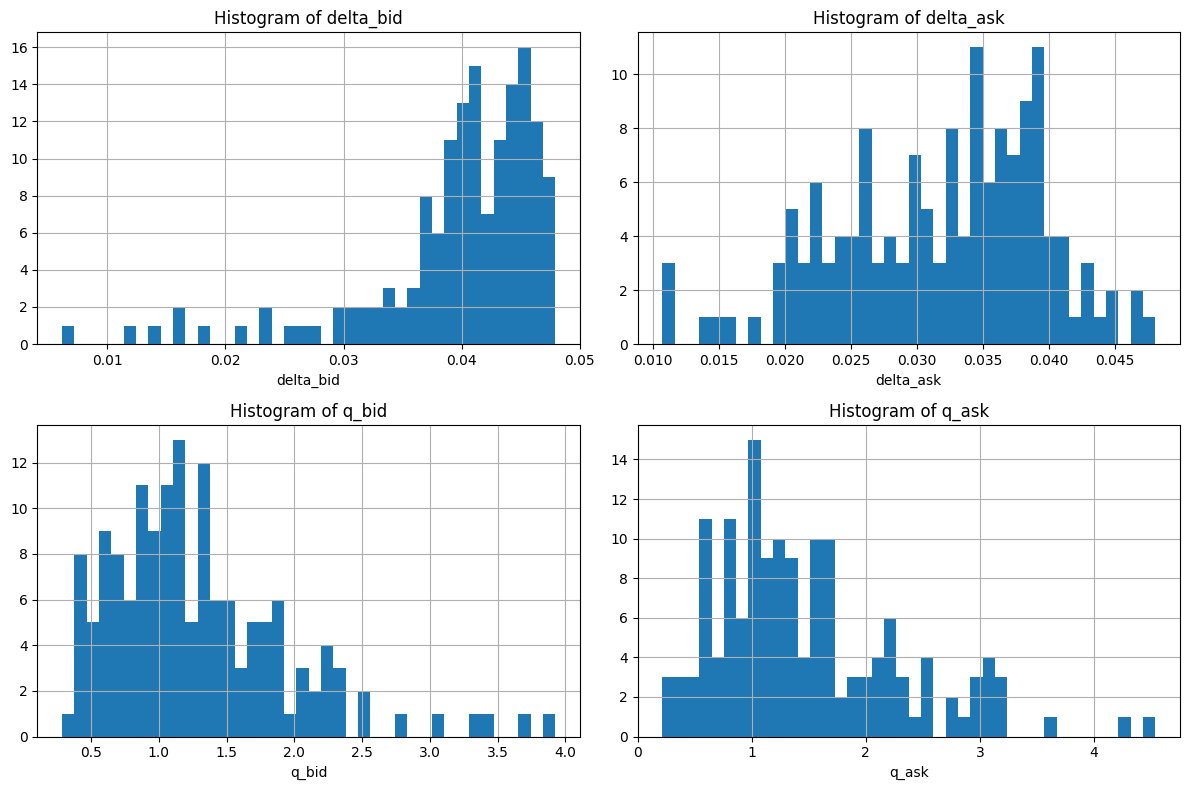

In [16]:
plot_action_histograms(ppo_rollout["actions"])

In [17]:
import torch

def _safe_hist(ax, x, bins=40, title="", xlabel=""):
    x = np.asarray(x).reshape(-1)
    x = x[np.isfinite(x)]
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(True)
    if len(x) == 0:
        ax.text(0.5, 0.5, "no finite values", ha="center", va="center",
                transform=ax.transAxes)
        return
    xmin, xmax = float(x.min()), float(x.max())
    if np.isclose(xmin, xmax):
        ax.axvline(xmin)
        ax.text(
            0.5, 0.85,
            f"constant ≈ {xmin:.4g}",
            ha="center",
            transform=ax.transAxes,
        )
        ax.set_xlim(xmin - 1e-3, xmax + 1e-3)
    else:
        ax.hist(x, bins=bins)

def plot_policy_latent_histograms(actor, states, device, bins=40):
    actor.eval()
    if not torch.is_tensor(states):
        states = torch.tensor(states, dtype=torch.float32, device=device)
    else:
        states = states.to(device)
    with torch.no_grad():
        mu, log_std = actor.forward(states)
        std = log_std.exp()
        mu = mu.detach().cpu().numpy()
        log_std = log_std.detach().cpu().numpy()
        std = std.detach().cpu().numpy()
    if mu.ndim == 1:
        mu = mu.reshape(-1, 1)
    if std.ndim == 1:
        std = std.reshape(-1, 1)
    if log_std.ndim == 1:
        log_std = log_std.reshape(-1, 1)
    n_dim = mu.shape[1]
    labels = ["delta_bid", "delta_ask", "q_bid", "q_ask"][:n_dim]
    fig, axes = plt.subplots(n_dim, 3, figsize=(14, 3 * n_dim))
    if n_dim == 1:
        axes = np.array([axes])
    for i in range(n_dim):
        _safe_hist(
            axes[i, 0],
            mu[:, i],
            bins=bins,
            title=f"mu for {labels[i]}",
            xlabel="mu",
        )
        _safe_hist(
            axes[i, 1],
            log_std[:, i],
            bins=bins,
            title=f"log_std for {labels[i]}",
            xlabel="log_std",
        )
        _safe_hist(
            axes[i, 2],
            std[:, i],
            bins=bins,
            title=f"std for {labels[i]}",
            xlabel="std",
        )
    plt.tight_layout()
    plt.show()
    print("===== latent policy summary =====")
    for i, lab in enumerate(labels):
        print(f"{lab}:")
        print(f"  mu      min={mu[:, i].min(): .4f} | mean={mu[:, i].mean(): .4f} | max={mu[:, i].max(): .4f}")
        print(f"  log_std min={log_std[:, i].min(): .4f} | mean={log_std[:, i].mean(): .4f} | max={log_std[:, i].max(): .4f}")
        print(f"  std     min={std[:, i].min(): .4f} | mean={std[:, i].mean(): .4f} | max={std[:, i].max(): .4f}")
        print()

/Users/franciscegoat/mm-rl/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Device] Using mps


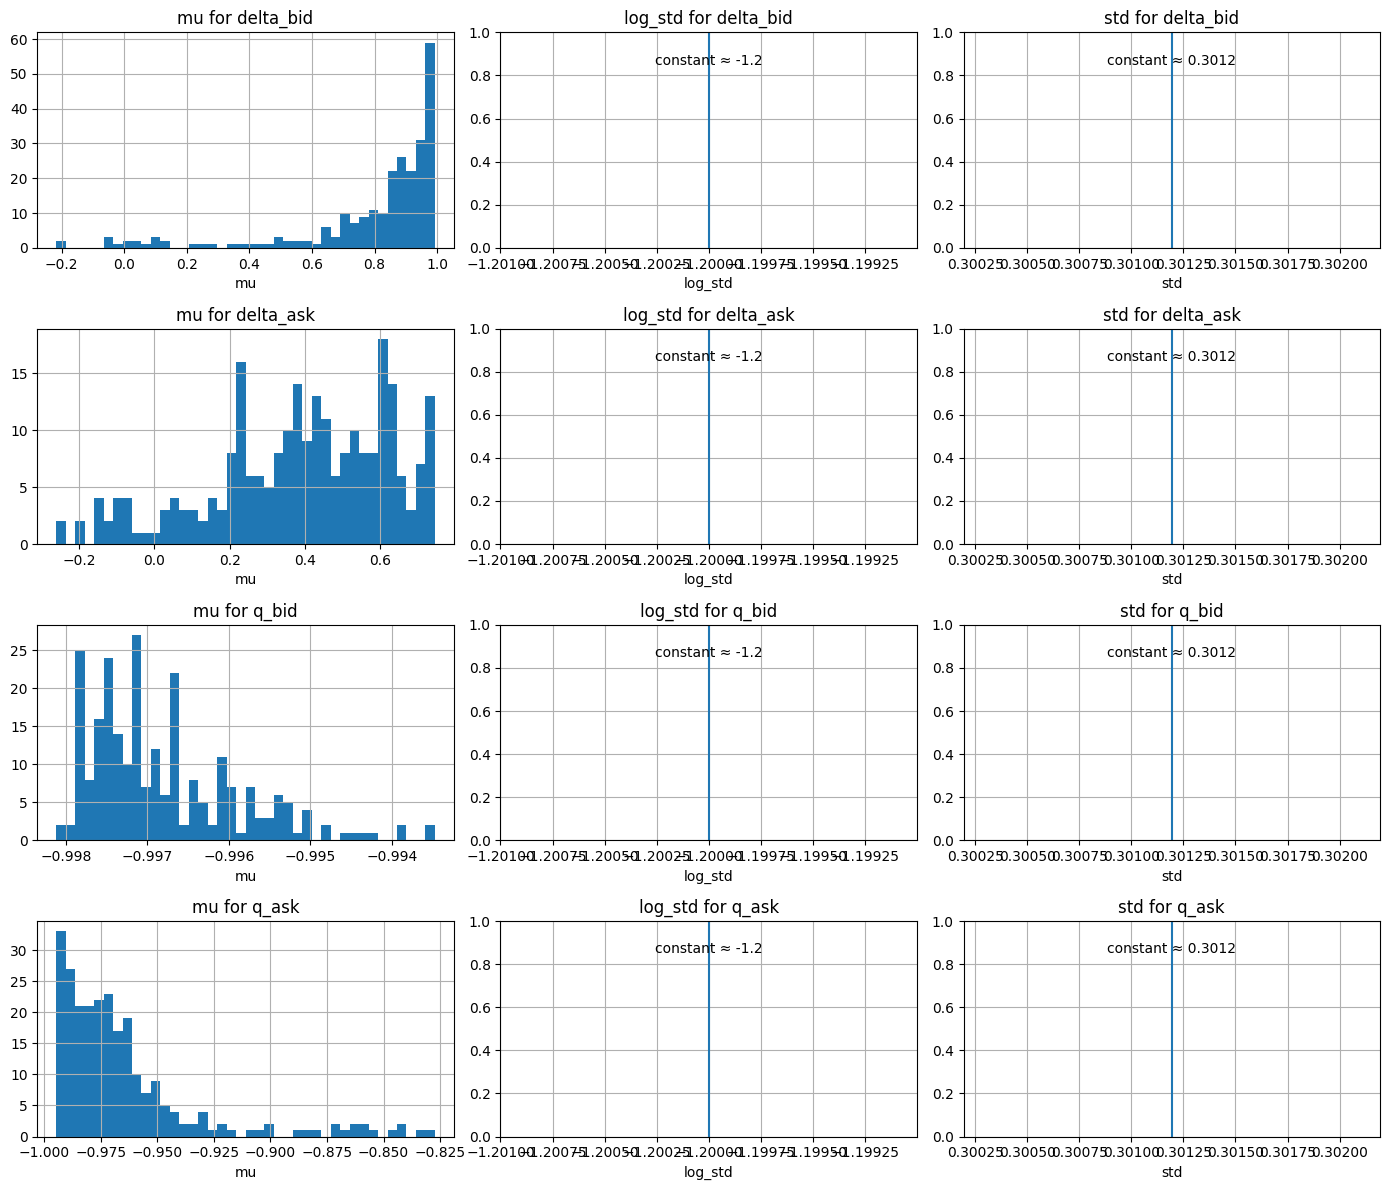

===== latent policy summary =====
delta_bid:
  mu      min=-0.2175 | mean= 0.7988 | max= 0.9928
  log_std min=-1.2000 | mean=-1.2000 | max=-1.2000
  std     min= 0.3012 | mean= 0.3012 | max= 0.3012

delta_ask:
  mu      min=-0.2600 | mean= 0.3886 | max= 0.7442
  log_std min=-1.2000 | mean=-1.2000 | max=-1.2000
  std     min= 0.3012 | mean= 0.3012 | max= 0.3012

q_bid:
  mu      min=-0.9981 | mean=-0.9968 | max=-0.9935
  log_std min=-1.2000 | mean=-1.2000 | max=-1.2000
  std     min= 0.3012 | mean= 0.3012 | max= 0.3012

q_ask:
  mu      min=-0.9947 | mean=-0.9644 | max=-0.8273
  log_std min=-1.2000 | mean=-1.2000 | max=-1.2000
  std     min= 0.3012 | mean= 0.3012 | max= 0.3012



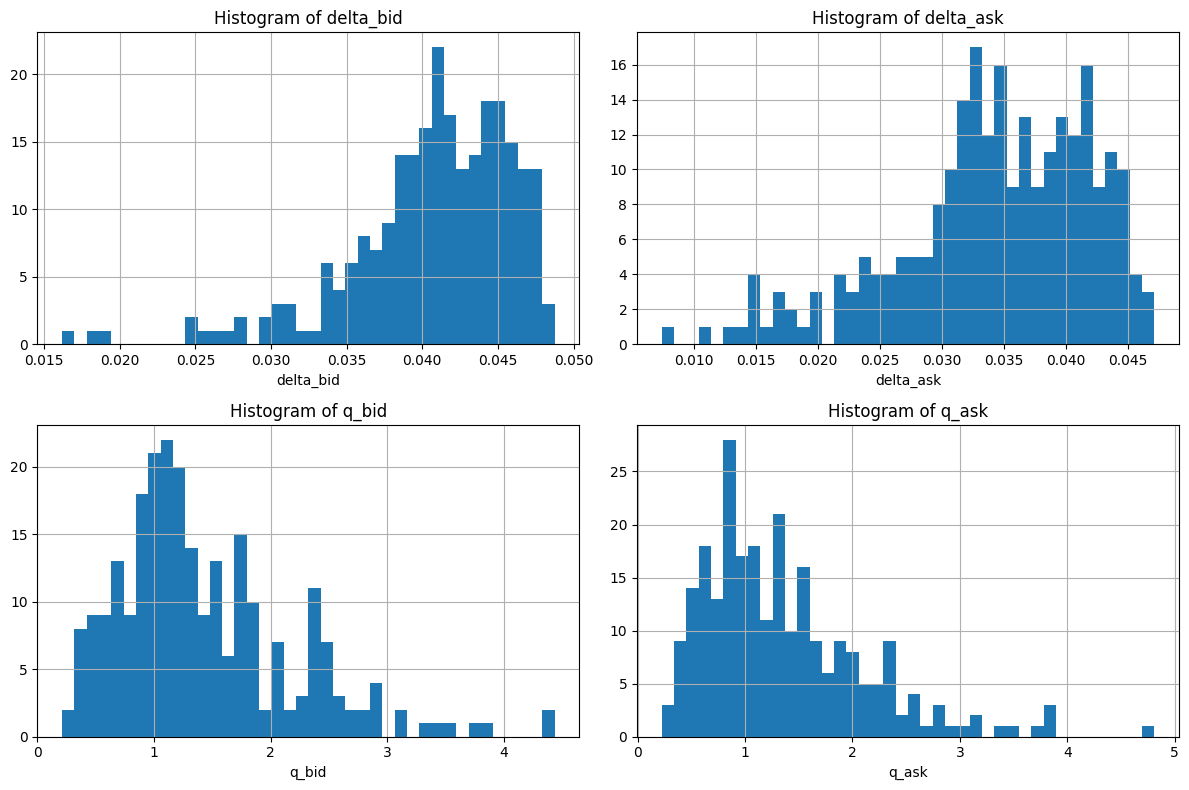

In [18]:
from scripts.train_loop import collect_trajectory

traj = collect_trajectory(env, actor, device=device, reset_rdm=True, max_steps=250)
plot_policy_latent_histograms(actor, traj["states"], device)
plot_action_histograms(traj["actions"].cpu().numpy())